In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the forecasting dataset (all sales, no customer ID needed)
df = pd.read_csv('data/processed/sales_for_forecasting.csv', parse_dates=['InvoiceDate'])
print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

# Aggregate into daily total sales (TotalPrice) across all products/customers
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y']  # Prophet requires these exact column names
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print(f"\nDaily sales shape: {daily_sales.shape}")
print(daily_sales.head())
print(daily_sales.tail())


C:\Users\HARSHAVARDHAN\AppData\Local\Temp\ipykernel_28060\1310358521.py:6: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/sales_for_forecasting.csv', parse_dates=['InvoiceDate'])


Loaded 1,041,670 rows
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Daily sales shape: (604, 2)
          ds         y
0 2009-12-01  54513.50
1 2009-12-02  63352.51
2 2009-12-03  74037.91
3 2009-12-04  40732.92
4 2009-12-05   9803.05
            ds          y
599 2011-12-05   88741.96
600 2011-12-06   56713.21
601 2011-12-07   75439.16
602 2011-12-08   82495.00
603 2011-12-09  200938.60


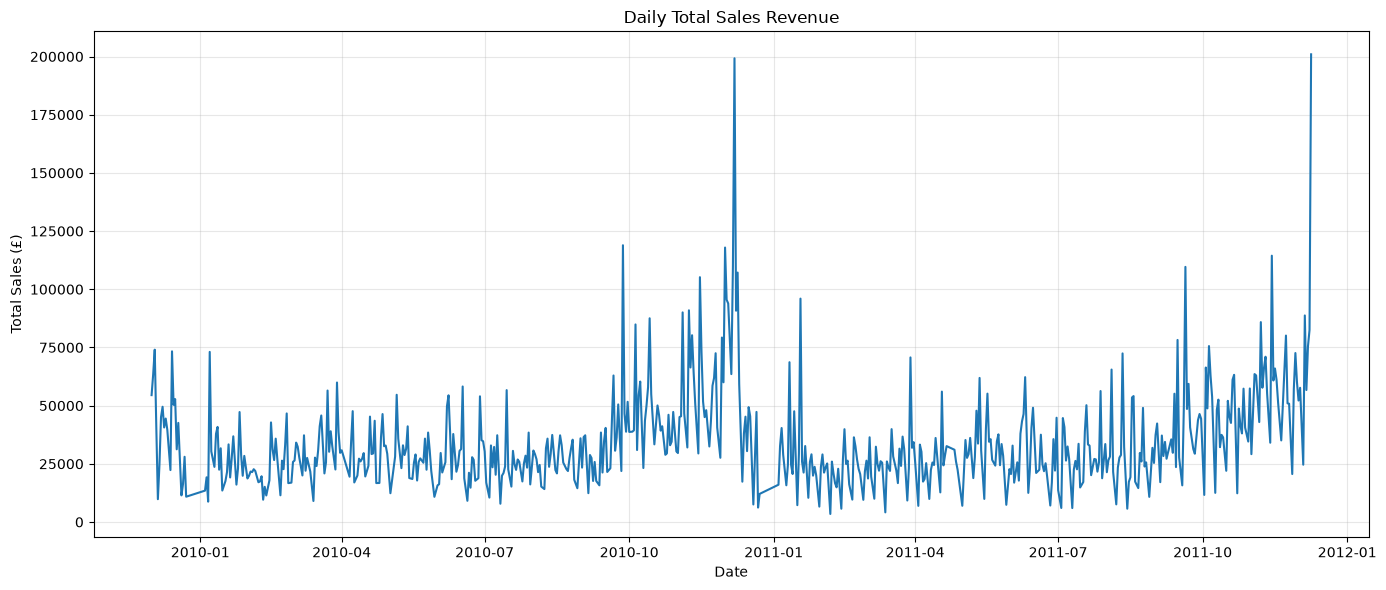

In [2]:
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['ds'], daily_sales['y'])
plt.title('Daily Total Sales Revenue')
plt.xlabel('Date')
plt.ylabel('Total Sales (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/daily_sales_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

In [3]:
date_range_full = pd.date_range(start=daily_sales['ds'].min(), end=daily_sales['ds'].max(), freq='D')
missing_dates = date_range_full.difference(daily_sales['ds'])
print(f"Expected days in range: {len(date_range_full)}")
print(f"Actual days with data: {len(daily_sales)}")
print(f"Missing days: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"Sample missing dates: {missing_dates[:10].tolist()}")

Expected days in range: 739
Actual days with data: 604
Missing days: 135
Sample missing dates: [Timestamp('2009-12-12 00:00:00'), Timestamp('2009-12-19 00:00:00'), Timestamp('2009-12-24 00:00:00'), Timestamp('2009-12-25 00:00:00'), Timestamp('2009-12-26 00:00:00'), Timestamp('2009-12-27 00:00:00'), Timestamp('2009-12-28 00:00:00'), Timestamp('2009-12-29 00:00:00'), Timestamp('2009-12-30 00:00:00'), Timestamp('2009-12-31 00:00:00')]


In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales['y'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")

if result[1] <= 0.05:
    print("\n✅ Series is likely STATIONARY (reject null hypothesis)")
else:
    print("\n⚠️ Series is likely NON-STATIONARY (fail to reject null hypothesis)")

ADF Statistic: -1.4024
p-value: 0.5811
Critical Values:
  1%: -3.4416
  5%: -2.8665
  10%: -2.5694

⚠️ Series is likely NON-STATIONARY (fail to reject null hypothesis)


C:\Users\HARSHAVARDHAN\AppData\Local\Temp\ipykernel_28060\2639889041.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(daily_sales['y'])


In [6]:
missing_df = pd.DataFrame({'date': missing_dates})
missing_df['day_name'] = missing_df['date'].dt.day_name()
print(missing_df['day_name'].value_counts())

day_name
Saturday     104
Monday        11
Friday         7
Sunday         6
Thursday       3
Tuesday        2
Wednesday      2
Name: count, dtype: int64


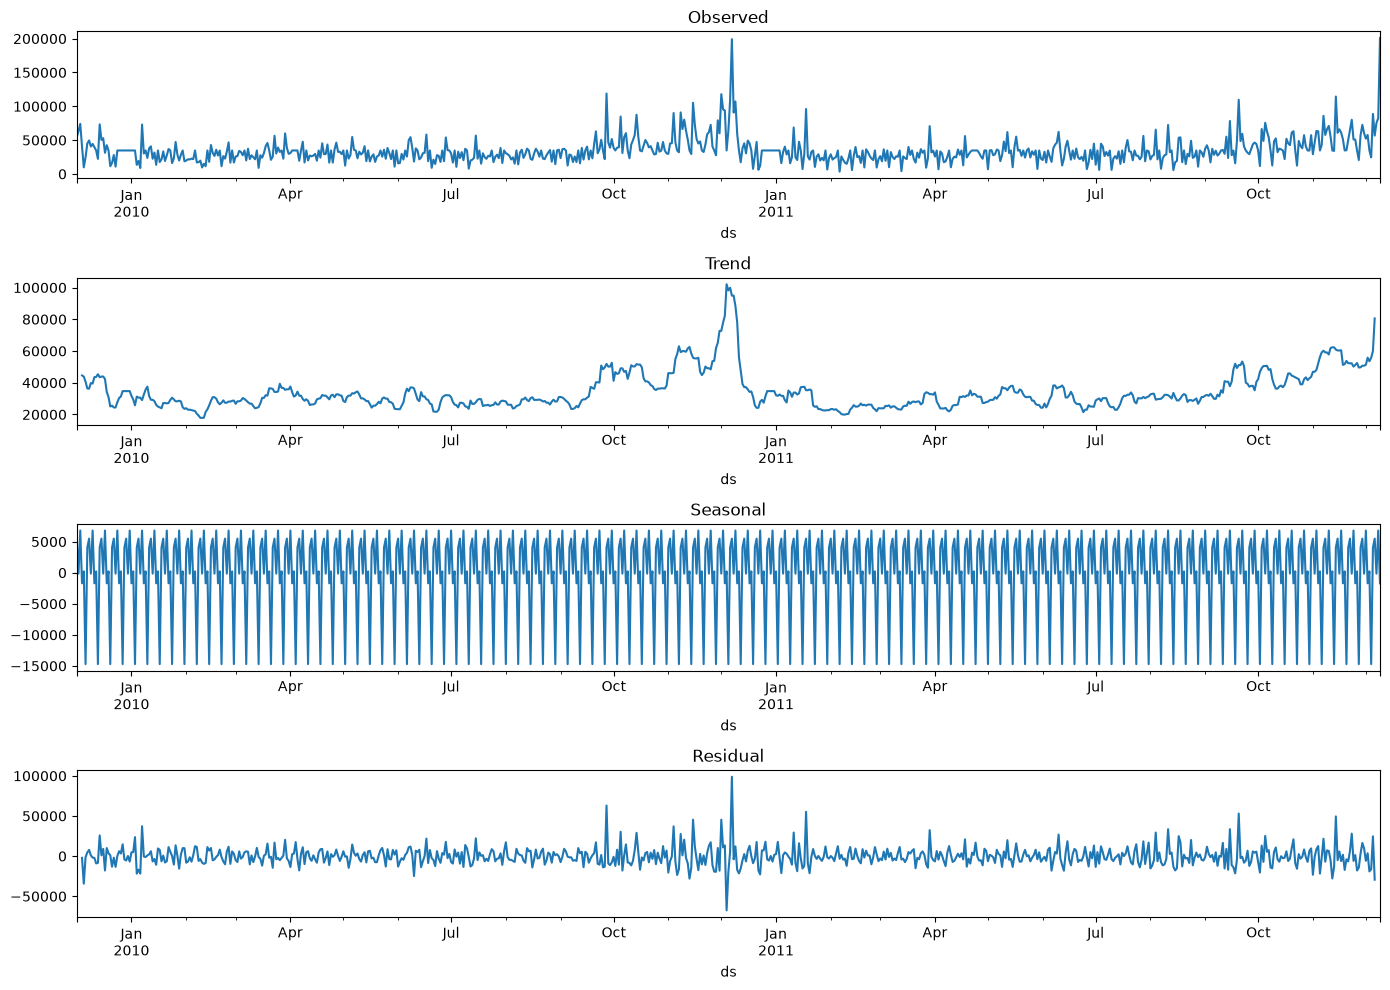

Decomposition complete - saved to docs/seasonal_decomposition.png


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set date as index for decomposition, fill missing dates with the daily mean (temporary, just for visualization)
ts = daily_sales.set_index('ds')['y'].asfreq('D')
ts_filled = ts.fillna(ts.mean())

decomposition = seasonal_decompose(ts_filled, model='additive', period=7)  # period=7 for weekly seasonality

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('docs/seasonal_decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

print("Decomposition complete - saved to docs/seasonal_decomposition.png")

In [8]:
# Reindex to full daily range, filling missing days with 0 (representing "closed" days)
ts_full = daily_sales.set_index('ds')['y'].asfreq('D', fill_value=0)

print(f"Full series length: {len(ts_full)}")
print(f"Days with 0 sales (closed): {(ts_full == 0).sum()}")
print(ts_full.head(15))

# Save this properly-prepared series for both Prophet and LSTM to use later
ts_full.to_csv('data/processed/daily_sales_timeseries.csv')
print("\n✅ Saved daily_sales_timeseries.csv")

Full series length: 739
Days with 0 sales (closed): 135
ds
2009-12-01    54513.50
2009-12-02    63352.51
2009-12-03    74037.91
2009-12-04    40732.92
2009-12-05     9803.05
2009-12-06    24613.64
2009-12-07    45083.35
2009-12-08    49517.23
2009-12-09    40616.09
2009-12-10    44442.11
2009-12-11    39659.60
2009-12-12        0.00
2009-12-13    22313.09
2009-12-14    73327.66
2009-12-15    50340.24
Freq: D, Name: y, dtype: float64

✅ Saved daily_sales_timeseries.csv
